This notebook examines how closely the learned policies reproduce real predator-prey behavior. First, pursuit and evasion are analyzed. Then, the collective motion of the swarm is evaluated using swarm-level metrics. Finally, modular policy networks are examined.

### Model Comparison Metrics

#### Set-up

In [ ]:
# install and then restart session after so that the new versions can be picked up
from google.colab import drive
drive.mount('/content/drive')

!pip install ema-pytorch geomloss[full] pykeops ultralytics deep-sort-realtime -q
!pip install -r /content/drive/MyDrive/Master-Thesis/requirements.txt -q
!pip install "numpy==2.0.2" --force-reinstall -q

In [ ]:
# mount + imports
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Predator Prey Thesis')
sys.path.insert(0, '/content/drive/MyDrive/Predator Prey Thesis')

import cv2
import torch
import pickle
import numpy as np
from pathlib import Path
from ema_pytorch import EMA
from datetime import datetime
from utils.sim_utils import *
from utils.eval_utils import *
from utils.train_utils import *
import matplotlib.pyplot as plt
from utils.experiments_utils import *
from utils.couzin_utils import *
from utils.vec_sim_utils import *
from utils.encoder_utils import *
from geomloss import SamplesLoss
from utils.mmd_loss import MMDLoss
from models.Generator import ModularPolicy
from models.Discriminator import Discriminator
from models.JointDiscriminator import JointDiscriminator
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_dir = Path('/content/drive/MyDrive/Predator Prey Thesis/data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16_attackonly')
PRED_ATTACK_BASE = '/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Raw/pred_attack'

# load init pool
init_pool_path = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Processed/init_pool/init_pool_16prey.pt')
init_pool = torch.load(init_pool_path).to(device)

#### GAIL Simulation

In [ ]:
# load GAIL policies
gail_prey_policy = ModularPolicy(features=6).to('cpu')
gail_prey_policy.load_state_dict(torch.load(run_dir / 'prey_policy_stage1.pth', map_location='cpu'))

gail_pred_policy = ModularPolicy(features=5).to('cpu')
gail_pred_policy.load_state_dict(torch.load(run_dir / 'pred_policy_stage1.pth', map_location='cpu'))

<All keys matched successfully>

In [ ]:
# run simulation with GAIL policies to get evaluation metrics
_, _, gail_metrics = run_env_simulation(visualization='off',
                                        prey_policy=gail_prey_policy,
                                        pred_policy=gail_pred_policy,
                                        n_prey=16, n_pred=1,
                                        max_steps=200,
                                        pred_speed=10, prey_speed=10,
                                        area_width=2160, area_height=2160,
                                        max_turn = 0.314,
                                        step_size=1.0,
                                        init_pool=init_pool)

#### BC Simulation

In [ ]:
# load BC policies
bc_path = Path('/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy')

bc_prey_policy = ModularPolicy(features=6).to('cpu')
bc_prey_policy.load_state_dict(torch.load(bc_path / 'bc_prey_policy_attack.pt', map_location='cpu'))

bc_pred_policy = ModularPolicy(features=5).to('cpu')
bc_pred_policy.load_state_dict(torch.load(bc_path / 'bc_pred_policy_attack.pt', map_location='cpu'))

<All keys matched successfully>

In [ ]:
# run simulation with BC policies to get evaluation metrics
_, _, bc_metrics = run_env_simulation(visualization='off',
                                    prey_policy=bc_prey_policy,
                                    pred_policy=bc_pred_policy,
                                    n_prey=16, n_pred=1,
                                    max_steps=200,
                                    pred_speed=10, prey_speed=10,
                                    area_width=2160, area_height=2160,
                                    max_turn = 0.314,
                                    step_size=1.0,
                                    init_pool=init_pool)

#### Couzin Simulation

In [ ]:
# run Couzin simulation to get evaluation metrics
_, _, couzin_metrics, _, _ = run_couzin_simulation(visualization="off", max_steps=200,
                                                constant_speed=10, shark_speed=10,
                                                area_width=2160, area_height=2160,
                                                dt = 1.0, # step_size
                                                alpha=0.01, # social behavior - attack only
                                                theta_dot_max=0.56, theta_dot_max_shark=0.56,
                                                number_of_sharks=1, n=16)

#### Random Policy Simulation

In [ ]:
# create random policies
random_prey_policy = ModularPolicy(features=6).to("cpu")
random_prey_policy.set_parameters()

random_pred_policy = ModularPolicy(features=5).to("cpu")
random_pred_policy.set_parameters()

# run simulation with random policies to get evaluation metrics
_, _, random_metrics = run_env_simulation(visualization='off',
                                        prey_policy=random_prey_policy,
                                        pred_policy=random_pred_policy,
                                        n_prey=16, n_pred=1,
                                        max_steps=200,
                                        pred_speed=10, prey_speed=10,
                                        area_width=2160, area_height=2160,
                                        max_turn = 0.314,
                                        step_size=1.0,
                                        init_pool=init_pool)

#### Visualizations

In [ ]:
expert_attack_16 = compute_attack_expert_metrics(os.path.join(PRED_ATTACK_BASE, 'pred_attack_16'))

  Found 27 attack JSONs in /content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Raw/pred_attack/pred_attack_16
    polarization           mean +0.5734  (n=1674)
    angular_momentum       mean +0.0301  (n=1674)
    sparsity               mean +0.0551  (n=1674)
    distance_to_predator   mean +0.2641  (n=1674)
    distance_nearest_prey  mean +0.0326  (n=1674)
    escape_alignment       mean +0.3274  (n=1674)
    pursuit_alignment      mean +0.5545  (n=1674)
    closing_speed          mean +2.4318  (n=1593)
    reorientation          mean -0.0026  (n=1647)
    nearest_distance       mean +70.3620  (n=1674)


Predator Pursuit Metrics

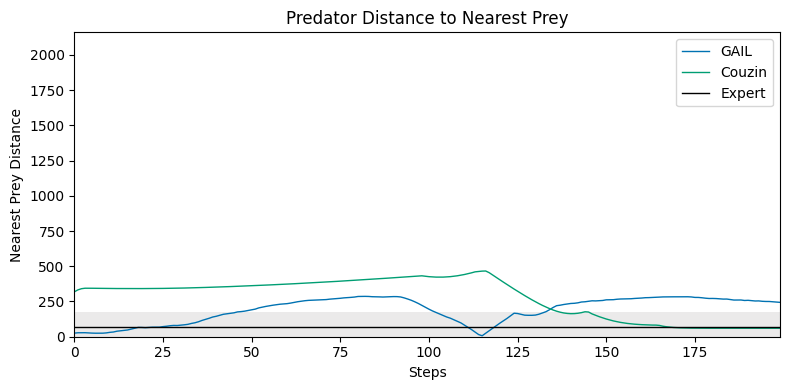

(np.float64(70.36203190654275), np.float64(106.56751095202152))

In [ ]:
# prey distance
plot_nearest_prey_distance(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

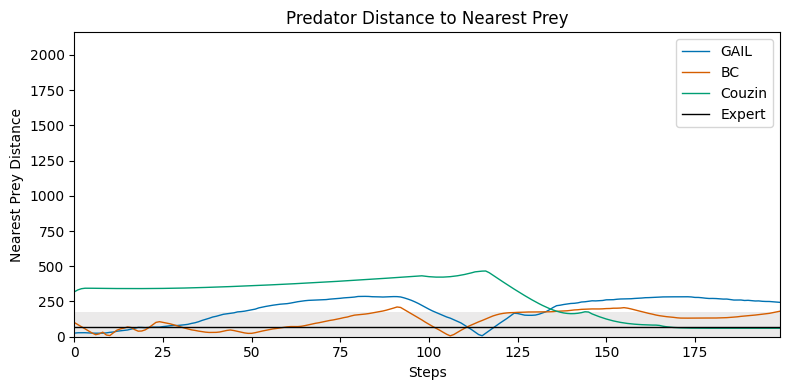

(np.float64(70.36203190654275), np.float64(106.56751095202152))

In [ ]:
# prey distance
plot_nearest_prey_distance(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

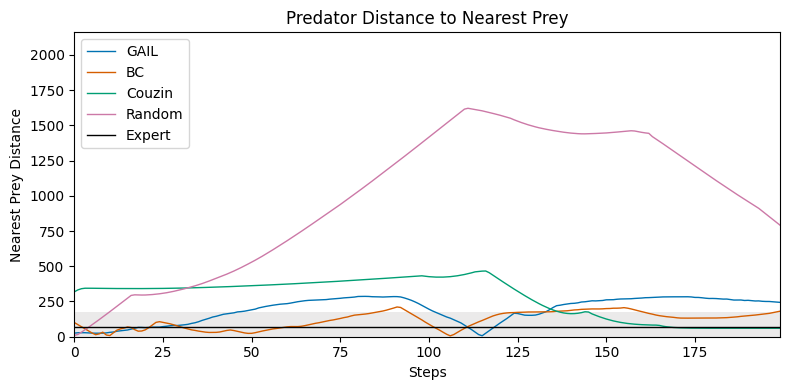

(np.float64(70.36203190654275), np.float64(106.56751095202152))

In [ ]:
# prey distance
plot_nearest_prey_distance(gail_metrics, bc_metrics, couzin_metrics, random_metrics,
                       expert_attack_16)

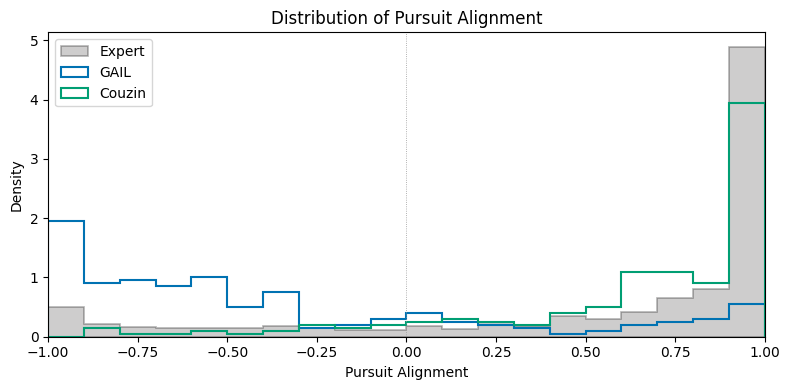

    Expert   mean +0.554   towards nearest prey in  81.5% of steps
    GAIL     mean -0.373   towards nearest prey in  24.5% of steps
    Couzin   mean +0.646   towards nearest prey in  89.5% of steps


(np.float64(0.5544906231967495), np.float64(0.6154152482076647))

In [ ]:
# pursuit alignment
plot_pursuit_alignment(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

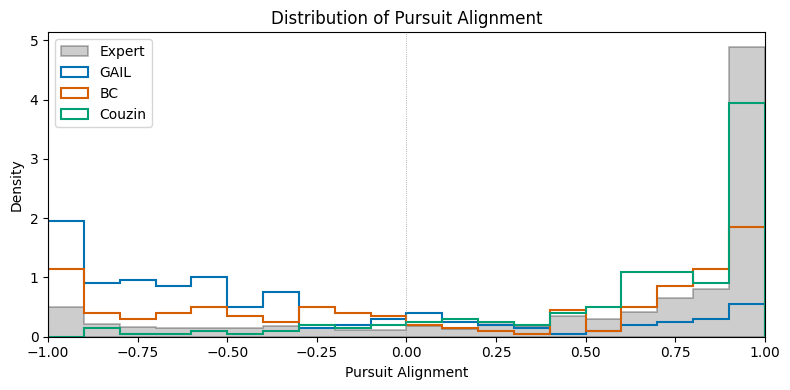

    Expert   mean +0.554   towards nearest prey in  81.5% of steps
    GAIL     mean -0.373   towards nearest prey in  24.5% of steps
    BC       mean +0.140   towards nearest prey in  54.0% of steps
    Couzin   mean +0.646   towards nearest prey in  89.5% of steps


(np.float64(0.5544906231967495), np.float64(0.6154152482076647))

In [ ]:
# pursuit alignment
plot_pursuit_alignment(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

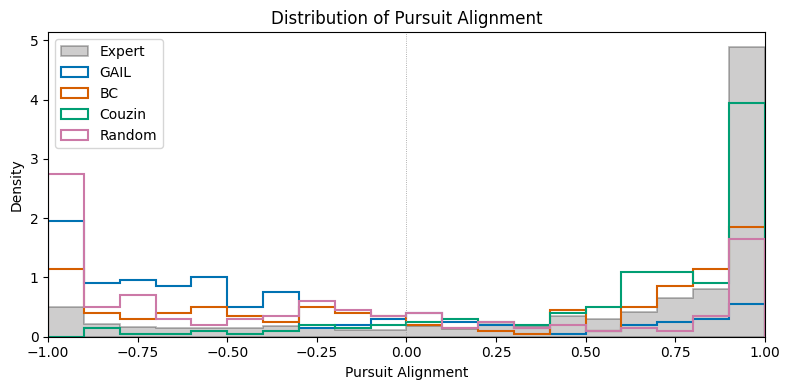

    Expert   mean +0.554   towards nearest prey in  81.5% of steps
    GAIL     mean -0.373   towards nearest prey in  24.5% of steps
    BC       mean +0.140   towards nearest prey in  54.0% of steps
    Couzin   mean +0.646   towards nearest prey in  89.5% of steps
    Random   mean -0.204   towards nearest prey in  35.0% of steps


(np.float64(0.5544906231967495), np.float64(0.6154152482076647))

In [ ]:
# pursuit alignment
plot_pursuit_alignment(gail_metrics, bc_metrics, couzin_metrics, random_metrics, expert_attack_16)

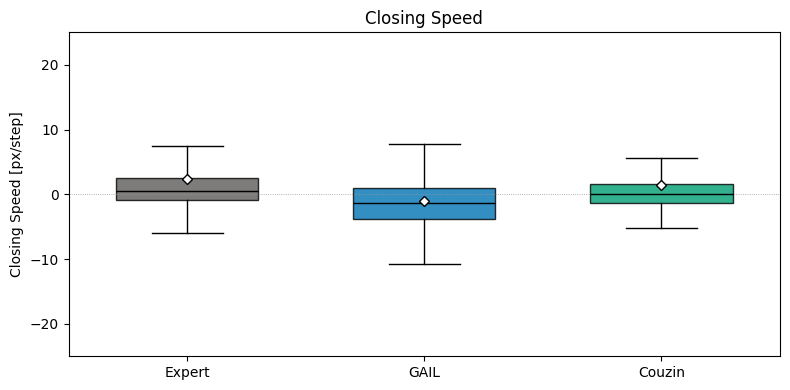

    Expert   mean   +2.432   median   +0.497   n=1593
    GAIL     mean   -1.110   median   -1.416   n=197
    Couzin   mean   +1.373   median   -0.026   n=197


(np.float64(2.4317929774437426), np.float64(9.959051888141884))

In [ ]:
# closing speed
plot_closing_speed(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

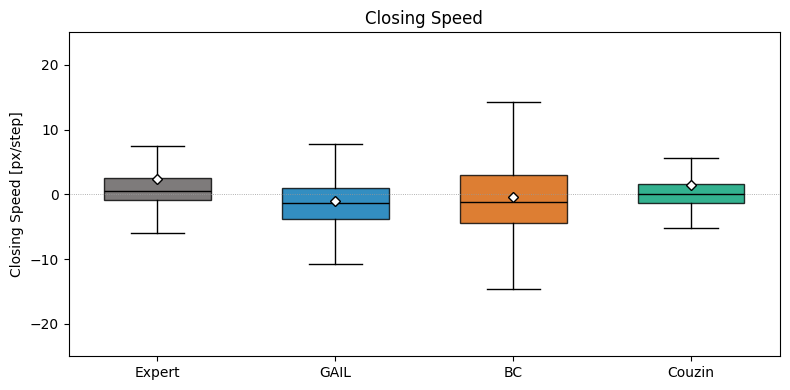

    Expert   mean   +2.432   median   +0.497   n=1593
    GAIL     mean   -1.110   median   -1.416   n=197
    BC       mean   -0.458   median   -1.163   n=197
    Couzin   mean   +1.373   median   -0.026   n=197


(np.float64(2.4317929774437426), np.float64(9.959051888141884))

In [ ]:
# closing speed
plot_closing_speed(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

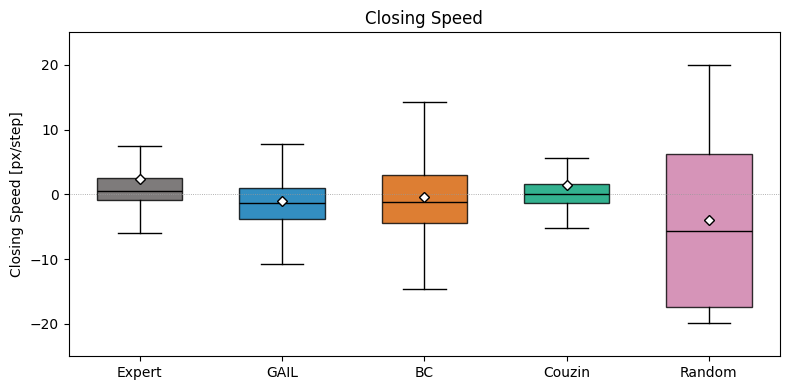

    Expert   mean   +2.432   median   +0.497   n=1593
    GAIL     mean   -1.110   median   -1.416   n=197
    BC       mean   -0.458   median   -1.163   n=197
    Couzin   mean   +1.373   median   -0.026   n=197
    Random   mean   -4.021   median   -5.622   n=197


(np.float64(2.4317929774437426), np.float64(9.959051888141884))

In [ ]:
# closing speed
plot_closing_speed(gail_metrics, bc_metrics, couzin_metrics, random_metrics, expert_attack_16)

Prey Evasion Metrics

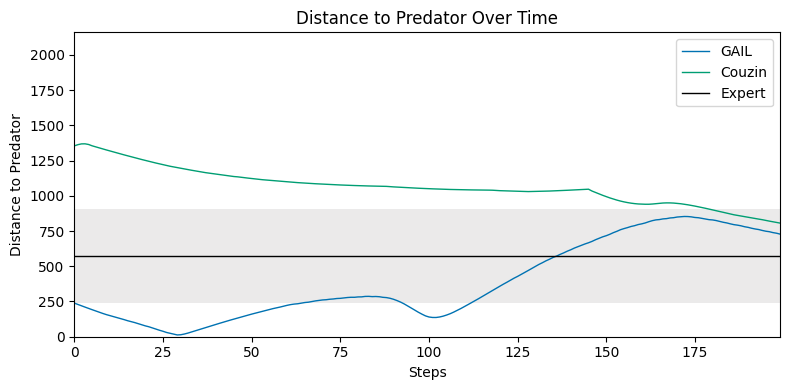

(np.float64(570.415156482107), np.float64(333.19660505889357))

In [ ]:
# distance to predator
plot_distance_to_predator(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

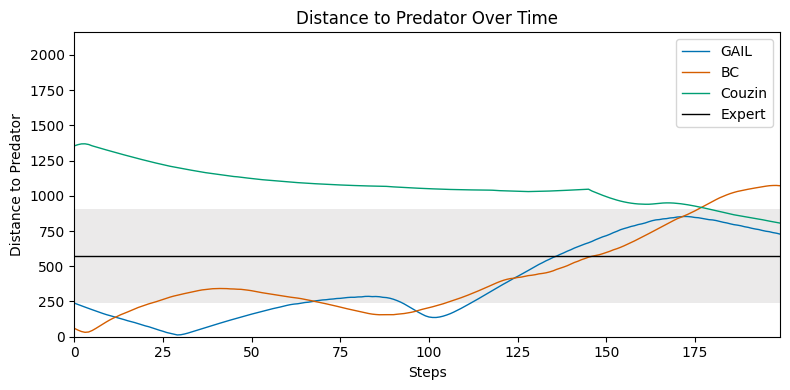

(np.float64(570.415156482107), np.float64(333.19660505889357))

In [ ]:
# distance to predator
plot_distance_to_predator(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

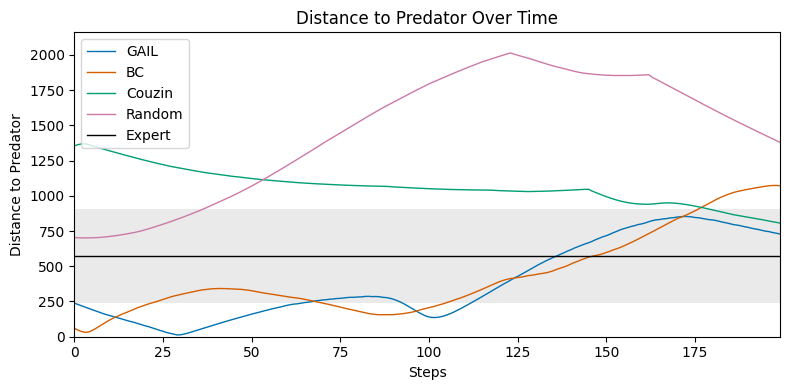

(np.float64(570.415156482107), np.float64(333.19660505889357))

In [ ]:
# distance to predator
plot_distance_to_predator(gail_metrics, bc_metrics, couzin_metrics, random_metrics,
                          expert_attack_16)

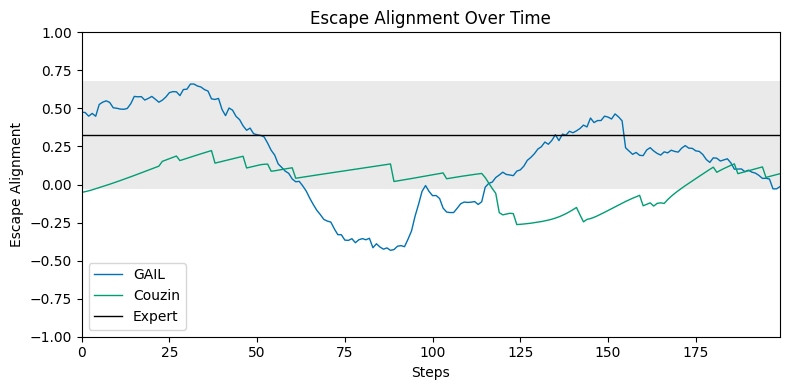

(np.float64(0.32743455864005644), np.float64(0.35573121322224605))

In [ ]:
# escape alignment
plot_escape_alignment(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

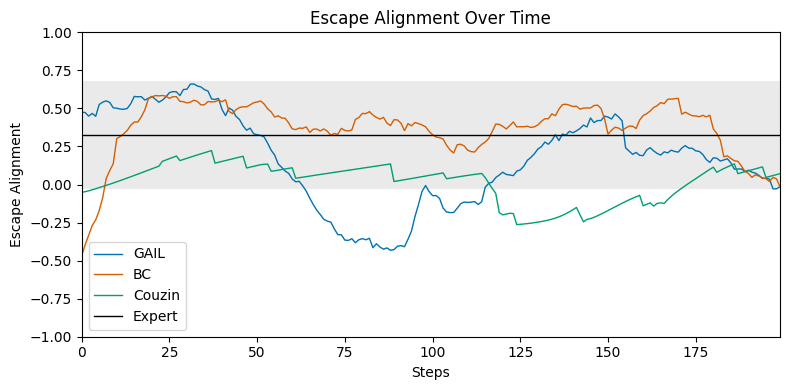

(np.float64(0.32743455864005644), np.float64(0.35573121322224605))

In [ ]:
# escape alignment
plot_escape_alignment(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

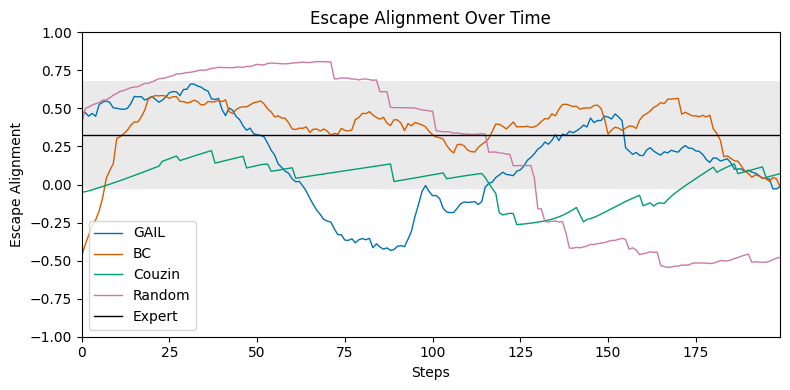

(np.float64(0.32743455864005644), np.float64(0.35573121322224605))

In [ ]:
# escape alignment
plot_escape_alignment(gail_metrics, bc_metrics, couzin_metrics, random_metrics,
                      expert_attack_16)

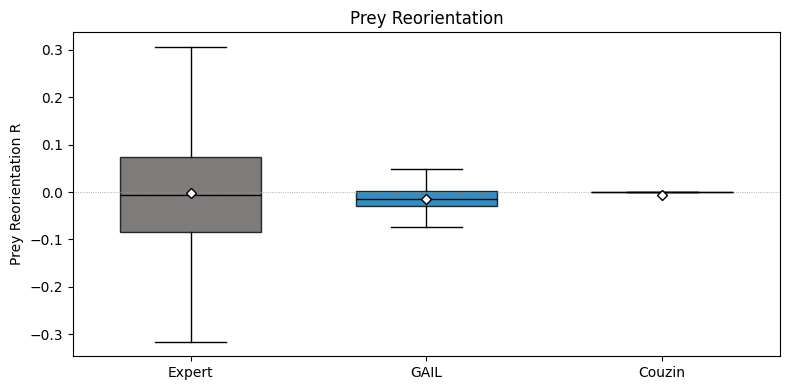

    Expert   mean   -0.003   median   -0.005   n=1647
    GAIL     mean   -0.015   median   -0.014   n=199
    Couzin   mean   -0.007   median   +0.000   n=199


(np.float64(-0.002602163007009026), np.float64(0.1347952788306109))

In [ ]:
# prey reorientation
plot_prey_reorientation(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

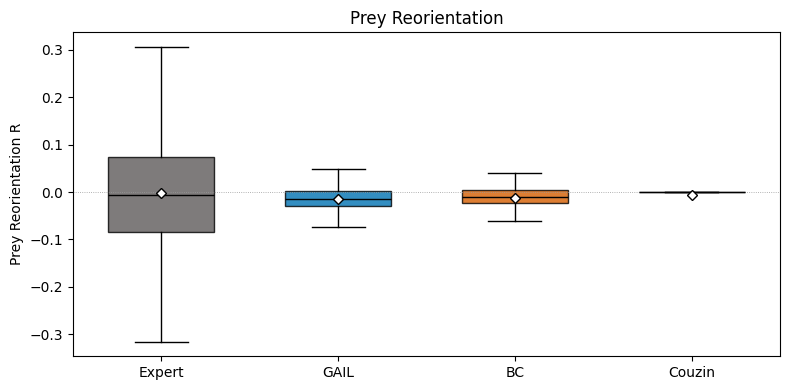

    Expert   mean   -0.003   median   -0.005   n=1647
    GAIL     mean   -0.015   median   -0.014   n=199
    BC       mean   -0.011   median   -0.011   n=199
    Couzin   mean   -0.007   median   +0.000   n=199


(np.float64(-0.002602163007009026), np.float64(0.1347952788306109))

In [ ]:
# prey reorientation
plot_prey_reorientation(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

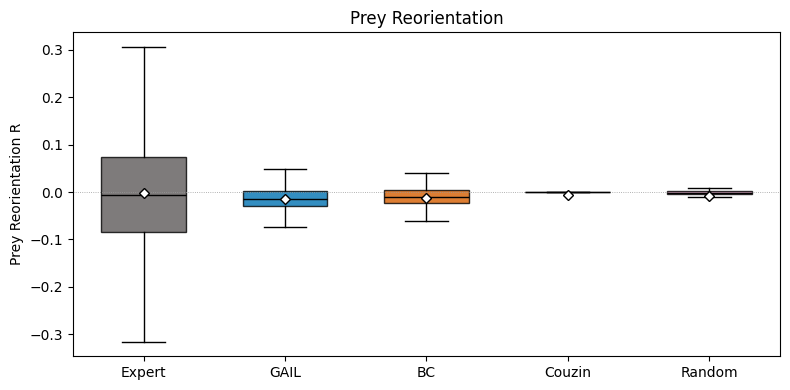

    Expert   mean   -0.003   median   -0.005   n=1647
    GAIL     mean   -0.015   median   -0.014   n=199
    BC       mean   -0.011   median   -0.011   n=199
    Couzin   mean   -0.007   median   +0.000   n=199
    Random   mean   -0.008   median   -0.001   n=199


(np.float64(-0.002602163007009026), np.float64(0.1347952788306109))

In [ ]:
# prey reorientation
plot_prey_reorientation(gail_metrics, bc_metrics, couzin_metrics, random_metrics,
                        expert_attack_16)

Swarm Metrics

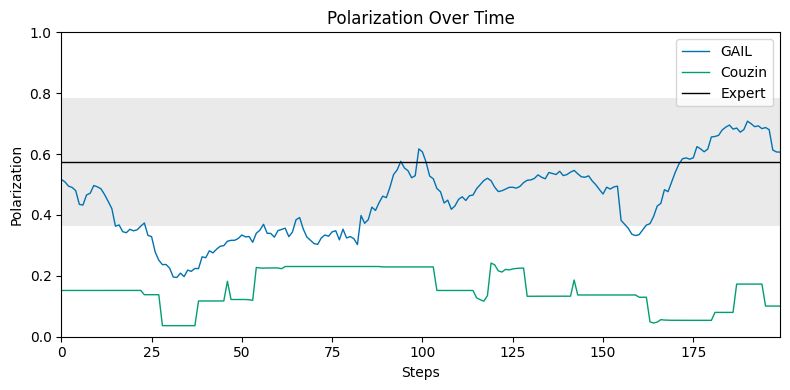

(np.float64(0.5733877729243411), np.float64(0.2095447055884207))

In [ ]:
# polarization
plot_polarization(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

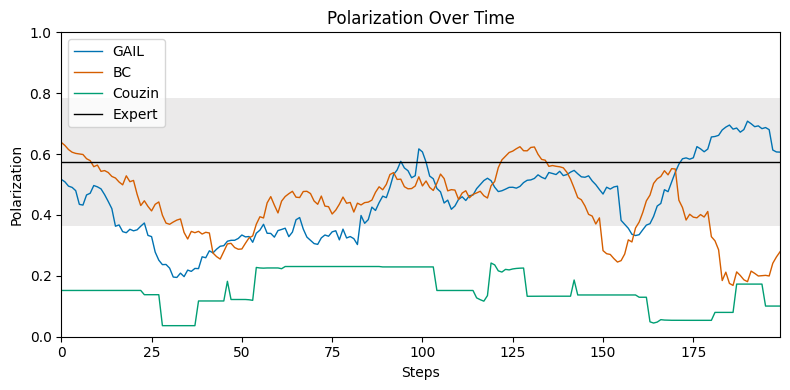

(np.float64(0.5733877729243411), np.float64(0.2095447055884207))

In [ ]:
# polarization
plot_polarization(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

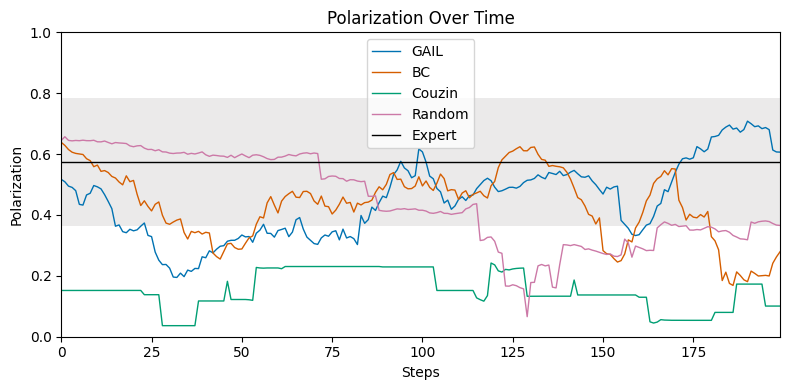

(np.float64(0.5733877729243411), np.float64(0.2095447055884207))

In [ ]:
# polarization
plot_polarization(gail_metrics, bc_metrics, couzin_metrics, random_metrics,
                  expert_attack_16)

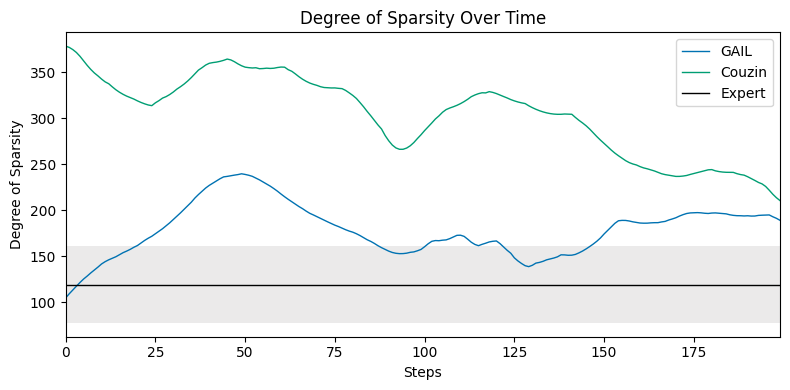

(np.float64(119.11164138780875), np.float64(41.73822505921866))

In [ ]:
# degree of sparsity
plot_degree_of_sparsity(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

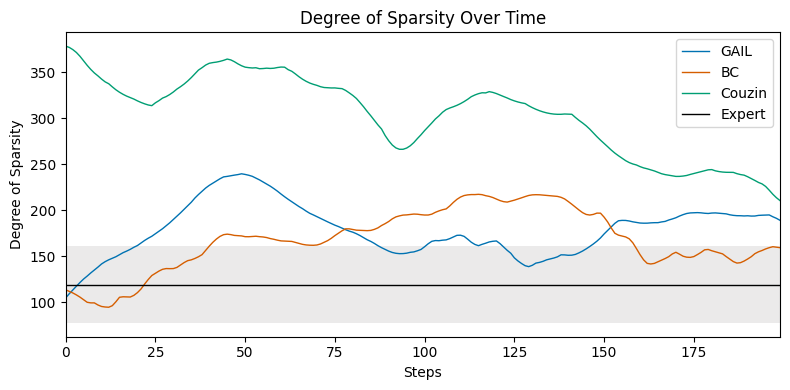

(np.float64(119.11164138780875), np.float64(41.73822505921866))

In [ ]:
# degree of sparsity
plot_degree_of_sparsity(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

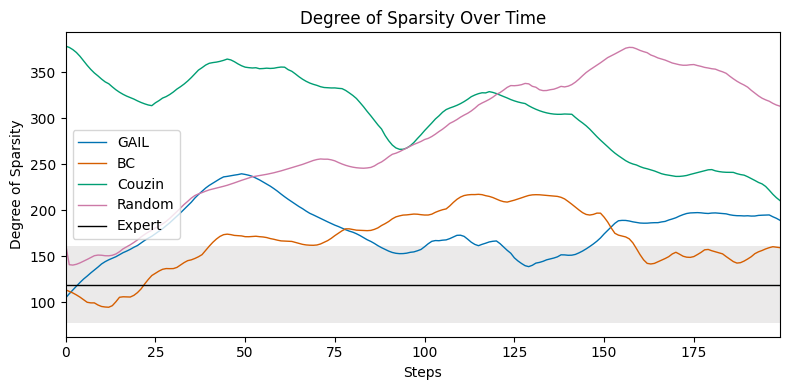

(np.float64(119.11164138780875), np.float64(41.73822505921866))

In [ ]:
# degree of sparsity
plot_degree_of_sparsity(gail_metrics, bc_metrics, couzin_metrics, random_metrics,
                        expert_attack_16)

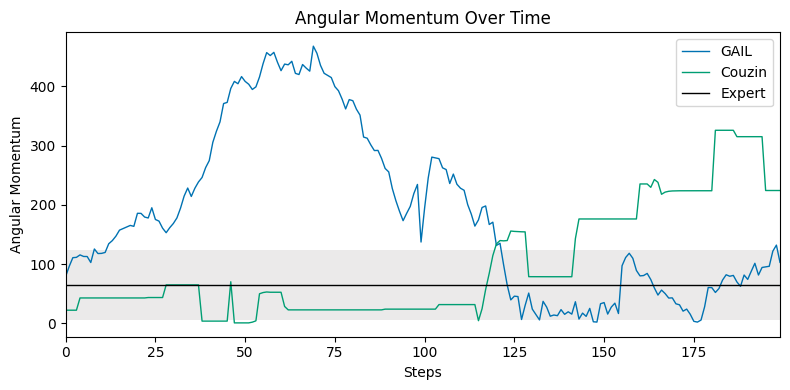

(np.float64(65.03778782316057), np.float64(58.50694372083989))

In [ ]:
# angular momentum
plot_angular_momentum(gail_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

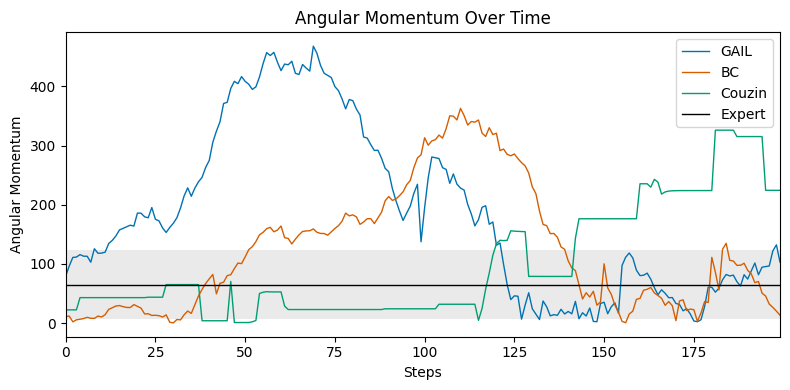

(np.float64(65.03778782316057), np.float64(58.50694372083989))

In [ ]:
# angular momentum
plot_angular_momentum(gail_metrics, bc_metrics=bc_metrics, couzin_metrics=couzin_metrics, expert_metrics=expert_attack_16)

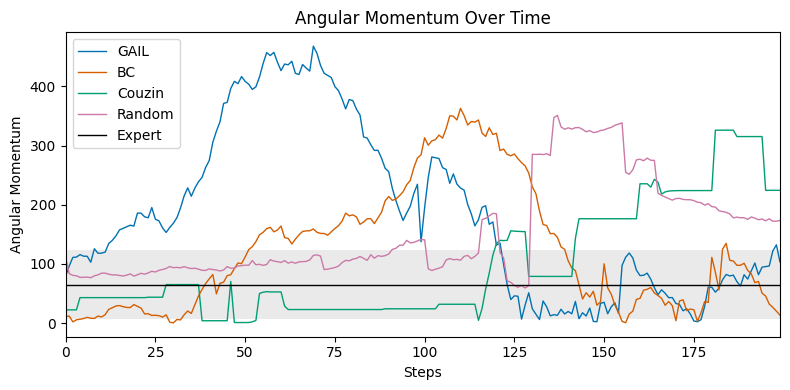

(np.float64(65.03778782316057), np.float64(58.50694372083989))

In [ ]:
# angular momentum
plot_angular_momentum(gail_metrics, bc_metrics, couzin_metrics, random_metrics,
                      expert_attack_16, save_as="angular_momentum_16prey")

### Analysis of Modular Networks

In [ ]:
# mount + imports
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Predator Prey Thesis')
sys.path.insert(0, '/content/drive/MyDrive/Predator Prey Thesis')

import cv2
import torch
import pickle
import numpy as np
from pathlib import Path
from ema_pytorch import EMA
from datetime import datetime
from utils.sim_utils import *
from utils.eval_utils import *
from utils.train_utils import *
import matplotlib.pyplot as plt
from utils.experiments_utils import *
from utils.couzin_utils import *
from utils.vec_sim_utils import *
from utils.encoder_utils import *
from geomloss import SamplesLoss
from utils.mmd_loss import MMDLoss
from models.Generator import ModularPolicy
from models.Discriminator import Discriminator
from models.JointDiscriminator import JointDiscriminator
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_dir = Path('/content/drive/MyDrive/Predator Prey Thesis/data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16_attackonly')

# load init pool
init_pool_path = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Processed/init_pool/init_pool_16prey.pt')
init_pool = torch.load(init_pool_path).to(device)

# load GAIL policies
gail_prey_policy = ModularPolicy(features=6).to('cpu')
gail_prey_policy.load_state_dict(torch.load(run_dir / 'prey_policy_stage1.pth', map_location='cpu'))

gail_pred_policy = ModularPolicy(features=5).to('cpu')
gail_pred_policy.load_state_dict(torch.load(run_dir / 'pred_policy_stage1.pth', map_location='cpu'))

<All keys matched successfully>

In [ ]:
# load predator and prey icons
pred_img_path = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/predator.png')
prey_img_path = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/prey.png')

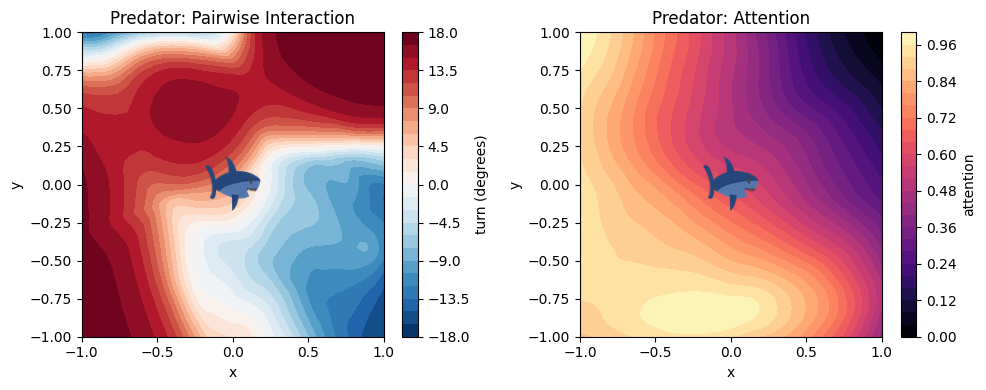

In [ ]:
# predator responding to prey
xs, ys, am, wm = compute_pin_an_maps(pin=gail_pred_policy.pairwise, an=gail_pred_policy.attention,
                                     role="predator", v_scale=0.15)
plot_policy_maps(xs, ys, am, wm, role="predator", img_path=pred_img_path,
                 titles=("Predator: Pairwise Interaction", "Predator: Attention"))

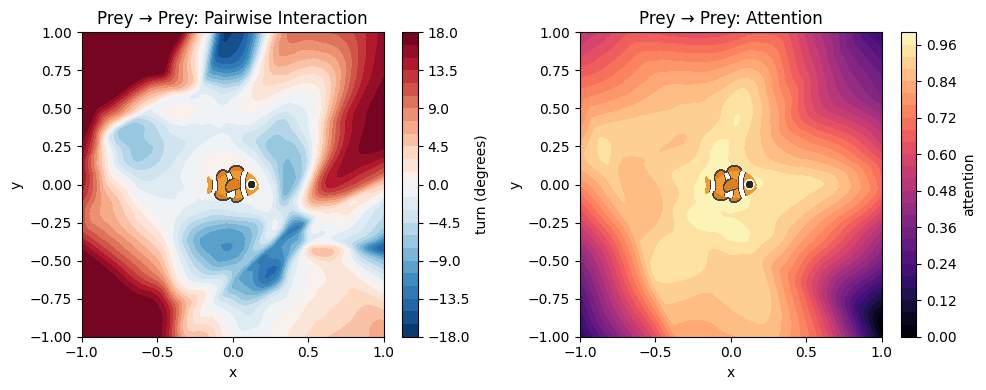

In [ ]:
# prey responding to another prey
xs, ys, am, wm = compute_pin_an_maps(pin=gail_prey_policy.pairwise, an=gail_prey_policy.attention,
                                     role="prey", v_scale=0.15)
plot_policy_maps(xs, ys, am, wm, role="prey", img_path=prey_img_path,
                 titles=("Prey → Prey: Pairwise Interaction", "Prey → Prey: Attention"))

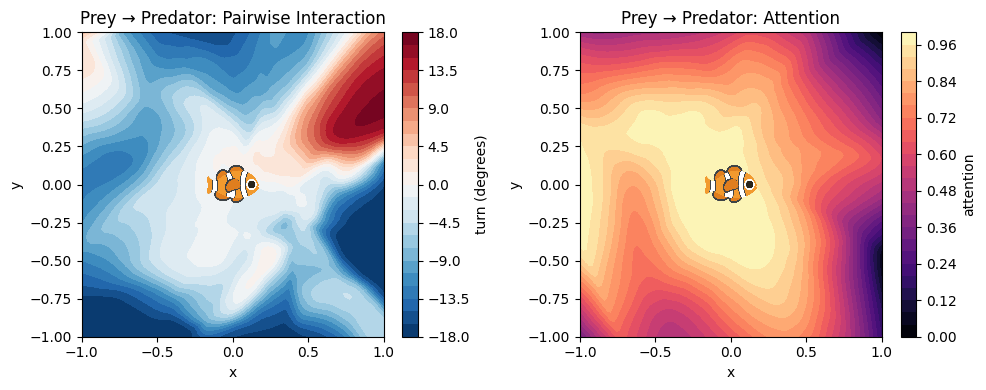

In [ ]:
# prey responding to the predator
xs, ys, am, wm = compute_pin_an_maps(pin=gail_prey_policy.pairwise, an=gail_prey_policy.attention,
                                     role="prey_pred", v_scale=0.15)
plot_policy_maps(xs, ys, am, wm, role="prey_pred", img_path=prey_img_path,
                 titles=("Prey → Predator: Pairwise Interaction", "Prey → Predator: Attention"))

In [ ]:
_, _, gail_metrics = run_env_simulation(
    visualization="off",
    prey_policy=gail_prey_policy,
    pred_policy=gail_pred_policy,
    n_prey=16,
    n_pred=1,
    max_steps=200,
    pred_speed=10,
    prey_speed=10,
    area_width=2160,
    area_height=2160,
    max_turn=0.314,
    step_size=1.0,
    max_speed_norm=25.0,
    init_pool=init_pool
)

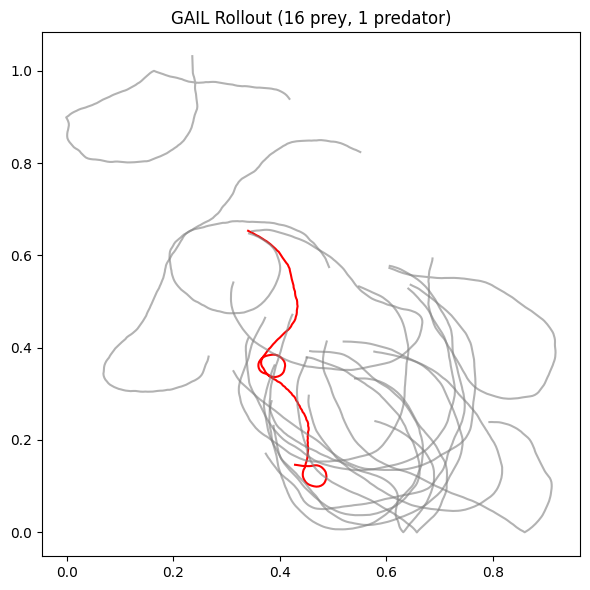

In [ ]:
# plot the trajectories of agents
plot_trajectory(gail_metrics, title="GAIL Rollout (16 prey, 1 predator)")